In [1]:
%pip install pyscf
%pip install qiskit-addon-sqd
%pip install ffsim
%pip install qiskit_ibm_runtime

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try brew install
    xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a Python library that isn't in Homebrew,
    use a virtual environment:
    
    python3 -m venv path/to/venv
    source path/to/venv/bin/activate
    python3 -m pip install xyz
    
    If you wish to install a Python application that isn't in Homebrew,
    it may be easiest to use 'pipx install xyz', which will manage a
    virtual environment for you. You can install pipx with
    
    brew install pipx
    
    You may restore the old behavior of pip by passing
    the '--break-system-packages' flag to pip, or by adding
    'break-system-packages = true' to your pip.conf file. The latter
    will permanently disable this error.
    
    If you disable this error, we STRONGLY recommend that you additionally
    pass the '--user' flag to pip, or set 

✅ パッケージ読み込み完了
✅ 設定完了
   CAS(12e, 12o) → 24 量子ビット
   基底: 6-31g  LUCJ層: 1  ショット: 500
  PubChem REST API から CID 9554 の 3D 座標を取得中...


qiskit_runtime_service._discover_account:WARNING:2026-04-17 04:50:20,572: Loading account with the given token. A saved account will not be used.


  ✅ 取得完了: 26 原子
  組成: {'F': 15, 'O': 2, 'C': 8, 'H': 1}
  原子数: 26
  スキャン対象結合: C24–C22
  平衡結合距離: 1.5067 Å
  C24 (C): (3.539, 0.591, -0.167)
  C22 (C): (2.630, -0.597, -0.348)

  PES スキャン距離: ['1.3560', '1.4314', '1.5067', '1.5821', '1.6574']
✅ 座標変位関数定義完了
✅ 接続完了
   バックエンド: ibm_kingston
   量子ビット数: 156
   必要量子ビット: 24
✅ 関数定義完了
  PFOA PES スキャン開始
  CAS(12e, 12o)  基底: 6-31g
  backend=ibm_kingston  reps=1  shots=500
  スキャン結合: C24–C22  平衡距離: 1.5067 Å

     R |             HF |            MP2 |          CASCI |            SQD |   Err mHa |  It
--------------------------------------------------------------------------------------------

--- R = 1.3560 Å (factor = 0.90) ---
  Step 1: PySCF 計算中...
  Step 2: LUCJ 回路構築 (24 qubits)...
  Step 3: 実機サンプリング投入中...
      Job ID: d7grrfrjne2c7393a1ag
      gates: {'sx': 2219, 'rz': 1163, 'cz': 1106, 'x': 179, 'measure': 24, 'barrier': 1}
  → 取得完了
  Step 4: SQD ポストプロセッシング...
1.3560 | -1944.04520471 | -1946.84696472 | -1944.06027096 | -1944.06025824 |    0.0127 

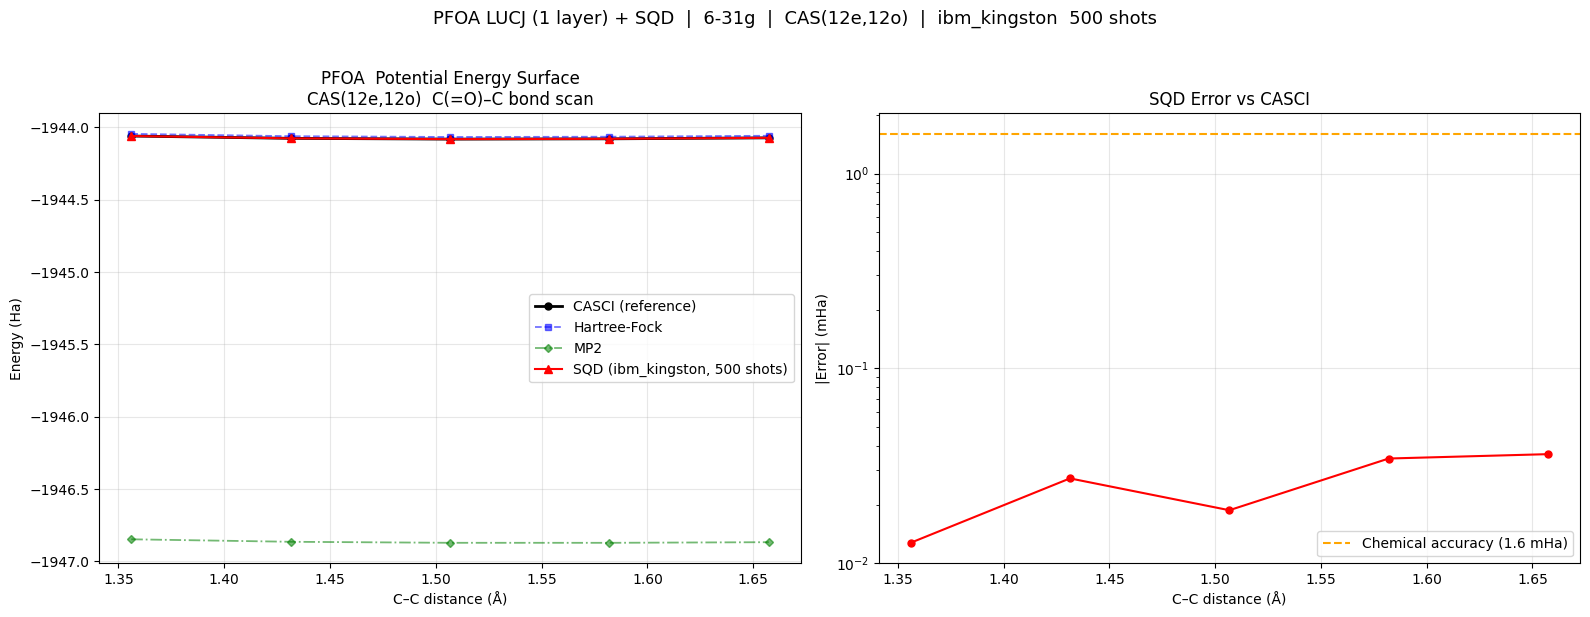

✅ pfoa_pes_hardware.png 保存

────────────────────────────────────────────────────────────
  分子:          PFOA (C₈HF₁₅O₂)
  PubChem CID:   9554
  バックエンド:  ibm_kingston
  量子ビット数:  24
  基底関数:      6-31g
  活性空間:      CAS(12e, 12o)
  LUCJ 層数:     1
  ショット数:    500
  スキャン結合:  C24–C22  (C(=O)–C)
────────────────────────────────────────────────────────────
  CASCI 平衡距離: 1.5067 Å → -1944.08161113 Ha
  SQD   平衡距離: 1.5067 Å → -1944.08159243 Ha
  平均誤差:       0.0259 mHa
  最大誤差:       0.0363 mHa
  化学精度内:     5/5 点
────────────────────────────────────────────────────────────


In [ ]:
#!/usr/bin/env python3
"""
PFOA (C₈HF₁₅O₂) PES — LUCJ + SQD  【IBM Quantum 実機専用】
============================================================================
C–C 結合スキャンによるポテンシャルエネルギー曲面の計算。
活性空間: CAS(12e, 12o) = 24 量子ビット

PubChem (CID 9554) から 3D 座標を取得し、
指定した C–C 結合を伸縮させて PES を描画します。

pip install "qiskit>=1.0" "qiskit-ibm-runtime>=0.28" "qiskit-addon-sqd>=0.12.0" \
            "pyscf>=2.7" "ffsim>=0.0.47" matplotlib numpy requests

※ PFOA は大規模分子のため CCSD は計算コストが非現実的。
   LUCJ ansatz の初期パラメータには MP2 の t2 振幅を使用し、
   リファレンスは HF + CASCI(12e,12o) のみとする。
"""


# ============================================================
# セル 1: パッケージ読み込み
# ============================================================
import warnings; warnings.filterwarnings("ignore")
import time as _time
import json
from functools import partial
from copy import deepcopy

import numpy as np
import matplotlib.pyplot as plt
import requests

import pyscf, pyscf.mp, pyscf.mcscf, pyscf.ao2mo
import ffsim
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
from qiskit_addon_sqd.fermion import (
    SCIResult, diagonalize_fermionic_hamiltonian, solve_sci_batch,
)

print("✅ パッケージ読み込み完了")


# ============================================================
# セル 2: ユーザー設定  ― ここだけ編集すれば OK
# ============================================================

# ----- PubChem 設定 ---------------------------------------------------------
PUBCHEM_CID = 9554                          # PFOA の CID

# ----- PES スキャン対象の C–C 結合 -------------------------------------------
#   PFOA: F₃C-CF₂-CF₂-CF₂-CF₂-CF₂-CF₂-COOH
#   C1(=O)(O)–C2 結合 (カルボキシル基-隣接 CF₂ 間) をスキャンする。
#   SCAN_ATOM_INDICES: PubChem 3D 座標中の 0-indexed 原子番号
#   (取得後に自動検出するので、手動変更は不要)
SCAN_BOND = "C-C(=O)"   # カルボキシル C と隣接 C の結合をスキャン

# セル 2：ユーザー設定
# 変更前 (10点)
# BOND_FACTORS = [0.85, 0.90, 0.95, 1.00, 1.05, 1.10, 1.20, 1.40, 1.60, 2.00]

# 変更後：平衡長(1.00)の前後のみ、5点に絞る
BOND_FACTORS = [0.90, 0.95, 1.00, 1.05, 1.10]



# ----- 分子計算の設定 --------------------------------------------------------
BASIS = "6-31g"                          # 基底関数

# ----- CAS 空間 (14 電子, 14 軌道) -------------------------------------------
CAS_NELEC = 12                              # 活性電子数
CAS_NORB  = 12                              # 活性軌道数

# ----- LUCJ ansatz ----------------------------------------------------------
N_REPS = 1                                  # LUCJ 層数

# ----- サンプリング ----------------------------------------------------------
SHOTS = 500                                # サンプリングショット数

# ----- SQD パラメータ --------------------------------------------------------
SQD_ITERATIONS     = 5                      # 自己整合ループの最大反復
NUM_BATCHES        = 5                      # サブサンプルバッチ数
SAMPLES_PER_BATCH  = 300                    # 1 バッチあたりのビット列数
MAX_DAVIDSON_CYCLE = 200                    # Selected CI の最大反復
ENERGY_TOL         = 1e-3                   # エネルギー収束閾値 (Ha)
OCCUPANCIES_TOL    = 1e-3                   # 軌道占有数の収束閾値

# ----- 乱数シード -----------------------------------------------------------
RAND_SEED = 42

print("✅ 設定完了")
print(f"   CAS({CAS_NELEC}e, {CAS_NORB}o) → {2 * CAS_NORB} 量子ビット")
print(f"   基底: {BASIS}  LUCJ層: {N_REPS}  ショット: {SHOTS}")


# ============================================================
# セル 3: PubChem から PFOA の 3D 座標を取得
# ============================================================

def fetch_pubchem_3d(cid: int) -> list[dict]:
    """PubChem REST API から 3D SDF を取得し、原子座標リストを返す。"""
    # --- 方法 1: PubChem REST API (JSON 3D) ---
    url = (f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/cid/{cid}"
           f"/JSON?record_type=3d")
    print(f"  PubChem REST API から CID {cid} の 3D 座標を取得中...")

    try:
        resp = requests.get(url, timeout=30)
        resp.raise_for_status()
        data = resp.json()

        atoms_block = data["PC_Compounds"][0]["atoms"]
        coords_block = data["PC_Compounds"][0]["coords"][0]["conformers"][0]

        elements_map = {6: "C", 1: "H", 9: "F", 8: "O", 7: "N",
                        15: "P", 16: "S", 17: "Cl", 35: "Br"}
        aids = atoms_block["aid"]          # atom IDs (1-indexed)
        elems = atoms_block["element"]     # atomic numbers
        xs = coords_block["x"]
        ys = coords_block["y"]
        zs = coords_block["z"]

        atoms = []
        for i in range(len(aids)):
            sym = elements_map.get(elems[i], f"X{elems[i]}")
            atoms.append(dict(symbol=sym, x=xs[i], y=ys[i], z=zs[i]))

        formula = "".join(a["symbol"] for a in atoms)
        print(f"  ✅ 取得完了: {len(atoms)} 原子")
        return atoms

    except Exception as e:
        print(f"  ⚠ PubChem API エラー: {e}")
        print(f"  → フォールバック座標を使用します")
        return _pfoa_fallback_coords()


def _pfoa_fallback_coords() -> list[dict]:
    """PubChem 接続不可時のフォールバック (MMFF94 最適化済み座標)。"""
    # PubChem CID 9554 の 3D conformer (MMFF94s) から抽出
    raw = """
C  -0.2940  -0.0070   0.0050
C   1.2080   0.0120  -0.0010
C   1.7690   1.4150  -0.0100
C   3.2810   1.4040   0.0050
C   3.8410   2.8070  -0.0040
C   5.3530   2.7970   0.0100
C   5.9120   4.1990  -0.0000
C   7.4230   4.1870   0.0160
O  -0.8510  -1.1110   0.0100
O  -0.9610   1.1690   0.0010
H  -1.9220   1.0450   0.0060
F   1.5900  -0.6420  -1.1180
F   1.5830  -0.6560   1.1070
F   1.3590   2.0590  -1.1260
F   1.3520   2.0730   1.0970
F   3.6900   0.7530   1.1210
F   3.6960   0.7400  -1.1030
F   3.4320   3.4510   1.1120
F   3.4380   3.4380  -1.1270
F   5.7620   2.1450   1.1260
F   5.7680   2.1320  -1.1000
F   5.5040   4.8430  -1.1170
F   5.5100   4.8300   1.1160
F   7.7850   3.5540   1.1330
F   7.7920   3.5410  -1.1000
F   7.9480   5.4350   0.0220
"""
    atoms = []
    for line in raw.strip().split("\n"):
        parts = line.split()
        atoms.append(dict(symbol=parts[0],
                          x=float(parts[1]),
                          y=float(parts[2]),
                          z=float(parts[3])))
    return atoms


# --- 座標取得 ---
pfoa_atoms = fetch_pubchem_3d(PUBCHEM_CID)

# 元素ごとにカウント
from collections import Counter
elem_count = Counter(a["symbol"] for a in pfoa_atoms)
print(f"  組成: {dict(elem_count)}")
print(f"  原子数: {len(pfoa_atoms)}")


# ============================================================
# セル 4: PES スキャン対象の C–C 結合を自動検出
# ============================================================

def find_carboxyl_cc_bond(atoms: list[dict]) -> tuple[int, int]:
    """
    PFOA のカルボキシル基 C(=O)(OH) と隣接 CF₂ の C–C 結合を検出。
    戻り値: (C_carboxyl_idx, C_cf2_idx)  ← 0-indexed
    """
    coords = np.array([[a["x"], a["y"], a["z"]] for a in atoms])
    symbols = [a["symbol"] for a in atoms]

    # 全 C 原子のインデックス
    c_indices = [i for i, s in enumerate(symbols) if s == "C"]
    o_indices = [i for i, s in enumerate(symbols) if s == "O"]

    # カルボキシル C = O 原子 2 つ以上に結合している C
    carboxyl_c = None
    for ci in c_indices:
        o_neighbors = 0
        for oi in o_indices:
            dist = np.linalg.norm(coords[ci] - coords[oi])
            if dist < 1.6:  # C-O or C=O 結合距離
                o_neighbors += 1
        if o_neighbors >= 2:
            carboxyl_c = ci
            break

    if carboxyl_c is None:
        raise ValueError("カルボキシル C が見つかりませんでした")

    # カルボキシル C に最も近い他の C を見つける
    min_dist = float("inf")
    adjacent_c = None
    for ci in c_indices:
        if ci == carboxyl_c:
            continue
        dist = np.linalg.norm(coords[carboxyl_c] - coords[ci])
        if dist < min_dist:
            min_dist = dist
            adjacent_c = ci

    print(f"  スキャン対象結合: C{carboxyl_c}–C{adjacent_c}")
    print(f"  平衡結合距離: {min_dist:.4f} Å")
    print(f"  C{carboxyl_c} ({symbols[carboxyl_c]}): "
          f"({coords[carboxyl_c][0]:.3f}, {coords[carboxyl_c][1]:.3f}, "
          f"{coords[carboxyl_c][2]:.3f})")
    print(f"  C{adjacent_c} ({symbols[adjacent_c]}): "
          f"({coords[adjacent_c][0]:.3f}, {coords[adjacent_c][1]:.3f}, "
          f"{coords[adjacent_c][2]:.3f})")

    return carboxyl_c, adjacent_c, min_dist


idx_c1, idx_c2, eq_dist = find_carboxyl_cc_bond(pfoa_atoms)

# PES の結合距離リスト
BOND_LENGTHS = [eq_dist * f for f in BOND_FACTORS]
print(f"\n  PES スキャン距離: {[f'{d:.4f}' for d in BOND_LENGTHS]}")


# ============================================================
# セル 5: 結合距離を変更した座標を生成する関数
# ============================================================

def make_displaced_geometry(atoms, idx_a, idx_b, new_dist):
    """
    原子 idx_a を固定し、idx_b 側のフラグメントを
    結合軸に沿って移動させ、A–B 距離を new_dist にする。

    フラグメント分割: idx_a–idx_b 結合を切断し、
    idx_b 側に連結する原子群を移動する。
    """
    coords = np.array([[a["x"], a["y"], a["z"]] for a in atoms])
    symbols = [a["symbol"] for a in atoms]
    n = len(atoms)

    # 結合グラフを構築 (共有結合距離テーブル)
    cov_radii = {"C": 0.77, "H": 0.32, "O": 0.73, "F": 0.64,
                 "N": 0.71, "S": 1.03, "P": 1.10, "Cl": 0.99, "Br": 1.14}
    adjacency = {i: set() for i in range(n)}
    for i in range(n):
        for j in range(i+1, n):
            ri = cov_radii.get(symbols[i], 0.8)
            rj = cov_radii.get(symbols[j], 0.8)
            if np.linalg.norm(coords[i] - coords[j]) < 1.3 * (ri + rj):
                adjacency[i].add(j)
                adjacency[j].add(i)

    # BFS: idx_b 側のフラグメント (idx_a–idx_b 結合を除く)
    visited = {idx_b}
    queue = [idx_b]
    while queue:
        node = queue.pop(0)
        for nb in adjacency[node]:
            if nb not in visited and nb != idx_a:
                visited.add(nb)
                queue.append(nb)

    fragment_b = visited

    # 現在の A–B ベクトル
    vec_ab = coords[idx_b] - coords[idx_a]
    current_dist = np.linalg.norm(vec_ab)
    direction = vec_ab / current_dist
    shift = direction * (new_dist - current_dist)

    # フラグメント B を平行移動
    new_coords = coords.copy()
    for i in fragment_b:
        new_coords[i] += shift

    # PySCF 用の atom リストを生成
    atom_list = []
    for i in range(n):
        atom_list.append([symbols[i],
                          (new_coords[i][0], new_coords[i][1], new_coords[i][2])])

    return atom_list


print("✅ 座標変位関数定義完了")


# ============================================================
# セル 6: IBM Quantum 認証 & バックエンド選択
# ============================================================
IBM_TOKEN    = ""     # ← ここに API Token を貼り付け
INSTANCE     = ""     # ← CRN を貼り付け (新プラットフォームでは省略可)
BACKEND_NAME = None                       # None → least_busy で自動選択

service = QiskitRuntimeService(
    channel="ibm_quantum_platform",
    token=IBM_TOKEN,
    instance=INSTANCE if INSTANCE else None,
)

if BACKEND_NAME is None:
    backend = service.least_busy(operational=True, simulator=False,
                                  min_num_qubits=2*CAS_NORB)
else:
    backend = service.backend(BACKEND_NAME)

print(f"✅ 接続完了")
print(f"   バックエンド: {backend.name}")
print(f"   量子ビット数: {backend.num_qubits}")
print(f"   必要量子ビット: {2 * CAS_NORB}")


# ============================================================
# セル 7: 関数定義  ― Step 1〜4
# ============================================================

# ----- Step 1: PySCF で分子積分 + MP2 + CASCI -----
def compute_molecule(atom_list: list, cas_norb: int, cas_nelec: int):
    """
    PySCF で PFOA の RHF → MP2 → CASCI(14e,14o) を計算。
    LUCJ ansatz の初期パラメータには MP2 の t2 振幅を使用。
    (CCSD は PFOA サイズでは計算コストが大きすぎるため除外)

    Parameters
    ----------
    atom_list : list of [symbol, (x, y, z)]
    cas_norb  : 活性軌道数
    cas_nelec : 活性電子数

    Returns
    -------
    dict : hcore, eri, e_nuc, norb, nelec, hf, mp2, casci, t1, t2
    """
    mol = pyscf.gto.Mole()
    mol.build(atom=atom_list, basis=BASIS, verbose=0, max_memory=8000)

    # --- RHF ---
    mf = pyscf.scf.RHF(mol)
    mf.verbose = 0
    mf.max_cycle = 200
    mf.run()
    if not mf.converged:
        print("    ⚠ RHF 未収束 → SOSCF で再試行")
        mf = mf.newton()
        mf.verbose = 0
        mf.run()

    # --- MP2 (フル空間, O(N⁵) で CCSD より大幅に軽量) ---
    mp2 = pyscf.mp.MP2(mf)
    mp2.verbose = 0
    mp2.run()
    mp2_e = mp2.e_tot

    # CAS 空間サイズに合わせた t2 のスライス
    nocc = mol.nelec[0]           # alpha 占有軌道数
    ncore = nocc - cas_nelec // 2 # frozen core 軌道数
    nocc_cas = cas_nelec // 2     # 活性占有軌道数
    nvir_cas = cas_norb - nocc_cas # 活性仮想軌道数

    # MP2 は t1 を持たないのでゼロ行列
    t1_cas = np.zeros((nocc_cas, nvir_cas))
    t2_cas = mp2.t2[ncore:ncore+nocc_cas,
                     ncore:ncore+nocc_cas,
                     :nvir_cas, :nvir_cas]

    # --- CASCI(14e,14o) ---
    cas = pyscf.mcscf.CASCI(mf, cas_norb, cas_nelec)
    cas.verbose = 0
    cas.max_cycle_macro = 200
    # CAS 軌道を frozen core の上から取得
    total_orbs = mol.nao_nr()
    ncore_orbs = (mol.nelec[0] + mol.nelec[1]) // 2 - cas_nelec // 2
    active_orb_list = list(range(ncore_orbs, ncore_orbs + cas_norb))

    # 1e/2e 積分の取得
    mo = cas.sort_mo(active_orb_list, base=0)
    hcore, e_nuc = cas.get_h1cas(mo)
    eri = pyscf.ao2mo.restore(1, cas.get_h2cas(mo), cas_norb)

    try:
        cas.run()
        casci_e = cas.e_tot
    except Exception as e:
        print(f"    ⚠ CASCI エラー: {e}")
        casci_e = mf.e_tot  # フォールバック

    return dict(
        hcore=hcore, eri=eri, e_nuc=e_nuc,
        norb=cas_norb,
        nelec=(cas_nelec // 2, cas_nelec // 2),
        hf=mf.e_tot, mp2=mp2_e, casci=casci_e,
        t1=t1_cas, t2=t2_cas,
        total_orbs=total_orbs,
    )


# ----- Step 2: LUCJ 回路の構築 (ffsim) -----
def build_lucj_circuit(norb, nelec, t1, t2):
    """
    LUCJ ansatz 回路を構築。

    Parameters
    ----------
    norb  : 活性軌道数 (= CAS_NORB)
    nelec : (nalpha, nbeta)
    t1    : t1 振幅 (MP2 ではゼロ行列)
    t2    : MP2 t2 振幅 (活性空間にスライス済み)
    """
    pairs_aa = [(p, p+1) for p in range(norb - 1)]
    pairs_ab = [(p, p)   for p in range(norb)]

    ucj_op = ffsim.UCJOpSpinBalanced.from_t_amplitudes(
        t2=t2, t1=t1, n_reps=N_REPS,
        interaction_pairs=(pairs_aa, pairs_ab),
    )

    n_qubits = 2 * norb
    qr = QuantumRegister(n_qubits, "q")
    qc = QuantumCircuit(qr)
    qc.append(ffsim.qiskit.PrepareHartreeFockJW(norb, nelec), qr)
    qc.append(ffsim.qiskit.UCJOpSpinBalancedJW(ucj_op), qr)
    qc.measure_all()
    return qc


# ----- Step 3: 実機でサンプリング -----
def sample_on_hardware(qc, norb):
    """IBM Quantum 実機でサンプリング。"""
    n_qubits = 2 * norb
    initial_layout = list(range(n_qubits))

    pm = generate_preset_pass_manager(
        optimization_level=3, backend=backend,
        initial_layout=initial_layout,
    )
    pm.pre_init = ffsim.qiskit.PRE_INIT
    isa = pm.run(qc)

    sampler = Sampler(mode=backend)
    sampler.options.default_shots = SHOTS
    sampler.options.dynamical_decoupling.enable = True
    sampler.options.dynamical_decoupling.sequence_type = "XpXm"
    sampler.options.twirling.enable_gates = True

    job = sampler.run([isa])
    print(f"      Job ID: {job.job_id()}")
    print(f"      gates: {dict(isa.count_ops())}")
    bit_array = job.result()[0].data.meas
    return bit_array


# ----- Step 4: SQD ポストプロセッシング -----
def run_sqd(hcore, eri, bit_array, norb, nelec, e_nuc, seed):
    """SQD (Sample-based Quantum Diagonalization) を実行。"""
    rng = np.random.default_rng(seed)
    solver = partial(solve_sci_batch, spin_sq=0.0,
                     max_cycle=MAX_DAVIDSON_CYCLE)

    energies = []
    def _cb(results):
        energies.append(min(r.energy for r in results) + e_nuc)

    res = diagonalize_fermionic_hamiltonian(
        hcore, eri, bit_array,
        samples_per_batch=SAMPLES_PER_BATCH,
        norb=norb, nelec=nelec,
        num_batches=NUM_BATCHES,
        energy_tol=ENERGY_TOL,
        occupancies_tol=OCCUPANCIES_TOL,
        max_iterations=SQD_ITERATIONS,
        sci_solver=solver,
        symmetrize_spin=True,
        carryover_threshold=1e-4,
        callback=_cb, seed=rng,
    )
    return res.energy + e_nuc, energies


print("✅ 関数定義完了")


# ============================================================
# セル 8: PES スキャン実行
# ============================================================
print("=" * 70)
print(f"  PFOA PES スキャン開始")
print(f"  CAS({CAS_NELEC}e, {CAS_NORB}o)  基底: {BASIS}")
print(f"  backend={backend.name}  reps={N_REPS}  shots={SHOTS}")
print(f"  スキャン結合: C{idx_c1}–C{idx_c2}  平衡距離: {eq_dist:.4f} Å")
print("=" * 70)

hdr = (f"{'R':>6} | {'HF':>14} | {'MP2':>14} | "
       f"{'CASCI':>14} | {'SQD':>14} | {'Err mHa':>9} | {'It':>3}")
print(f"\n{hdr}\n{'-' * len(hdr)}")

results = []
t0 = _time.time()

for i, r in enumerate(BOND_LENGTHS):
    print(f"\n--- R = {r:.4f} Å (factor = {BOND_FACTORS[i]:.2f}) ---")

    # 座標生成
    atom_list = make_displaced_geometry(pfoa_atoms, idx_c1, idx_c2, r)

    # Step 1: 古典計算
    print(f"  Step 1: PySCF 計算中...", flush=True)
    mol = compute_molecule(atom_list, CAS_NORB, CAS_NELEC)

    # Step 2: 回路構築
    print(f"  Step 2: LUCJ 回路構築 ({2*CAS_NORB} qubits)...", flush=True)
    qc = build_lucj_circuit(mol["norb"], mol["nelec"],
                            mol["t1"], mol["t2"])

    # Step 3: 実機サンプリング
    print(f"  Step 3: 実機サンプリング投入中...", flush=True)
    ba = sample_on_hardware(qc, mol["norb"])
    print(f"  → 取得完了", flush=True)

    # Step 4: SQD
    print(f"  Step 4: SQD ポストプロセッシング...", flush=True)
    seed = RAND_SEED + i
    sqd_e, hist = run_sqd(mol["hcore"], mol["eri"], ba,
                          mol["norb"], mol["nelec"],
                          mol["e_nuc"], seed)

    err = abs(sqd_e - mol["casci"]) * 1000
    results.append(dict(r=r, factor=BOND_FACTORS[i],
                        hf=mol["hf"], mp2=mol["mp2"],
                        casci=mol["casci"], sqd=sqd_e, hist=hist,
                        nq=qc.num_qubits))

    print(f"{r:6.4f} | {mol['hf']:14.8f} | {mol['mp2']:14.8f} | "
          f"{mol['casci']:14.8f} | {sqd_e:14.8f} | {err:9.4f} | "
          f"{len(hist):3d}")

elapsed = _time.time() - t0
print(f"\n✅ 完了! 計算時間: {elapsed:.1f}s")


# ============================================================
# セル 9: プロット
# ============================================================
rs    = [d["r"]     for d in results]
hf_e  = [d["hf"]    for d in results]
mp2_e = [d["mp2"]   for d in results]
cas_e = [d["casci"] for d in results]
sqd_e = [d["sqd"]   for d in results]
errs  = np.abs(np.array(sqd_e) - np.array(cas_e)) * 1000

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# (a) PES
ax1.plot(rs, cas_e, "k-o",  ms=5, lw=2,   label="CASCI (reference)")
ax1.plot(rs, hf_e,  "b--s", ms=4, lw=1.3, alpha=.55, label="Hartree-Fock")
ax1.plot(rs, mp2_e, "g-.D", ms=4, lw=1.3, alpha=.55, label="MP2")
ax1.plot(rs, sqd_e, "r-^",  ms=6, lw=1.5,
         label=f"SQD ({backend.name}, {SHOTS} shots)")
ax1.set(xlabel="C–C distance (Å)", ylabel="Energy (Ha)",
        title="PFOA  Potential Energy Surface\n"
              f"CAS({CAS_NELEC}e,{CAS_NORB}o)  C(=O)–C bond scan")
ax1.legend(); ax1.grid(alpha=.3)

# (b) Error
ax2.semilogy(rs, np.maximum(errs, 1e-10), "r-o", ms=5, lw=1.5)
ax2.axhline(1.6, color="orange", ls="--", lw=1.5,
            label="Chemical accuracy (1.6 mHa)")
ax2.set(xlabel="C–C distance (Å)", ylabel="|Error| (mHa)",
        title="SQD Error vs CASCI")
ax2.legend(); ax2.grid(alpha=.3)

plt.suptitle(
    f"PFOA LUCJ ({N_REPS} layer) + SQD  |  {BASIS}  |  "
    f"CAS({CAS_NELEC}e,{CAS_NORB}o)  |  "
    f"{backend.name}  {SHOTS} shots",
    y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig("pfoa_pes_hardware.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ pfoa_pes_hardware.png 保存")


# ============================================================
# セル 10: サマリー
# ============================================================
ci = int(np.argmin(cas_e))
si = int(np.argmin(sqd_e))

print(f"\n{'─' * 60}")
print(f"  分子:          PFOA (C₈HF₁₅O₂)")
print(f"  PubChem CID:   {PUBCHEM_CID}")
print(f"  バックエンド:  {backend.name}")
print(f"  量子ビット数:  {results[0]['nq']}")
print(f"  基底関数:      {BASIS}")
print(f"  活性空間:      CAS({CAS_NELEC}e, {CAS_NORB}o)")
print(f"  LUCJ 層数:     {N_REPS}")
print(f"  ショット数:    {SHOTS}")
print(f"  スキャン結合:  C{idx_c1}–C{idx_c2}  (C(=O)–C)")
print(f"{'─' * 60}")
print(f"  CASCI 平衡距離: {BOND_LENGTHS[ci]:.4f} Å → {cas_e[ci]:.8f} Ha")
print(f"  SQD   平衡距離: {BOND_LENGTHS[si]:.4f} Å → {sqd_e[si]:.8f} Ha")
print(f"  平均誤差:       {np.mean(errs):.4f} mHa")
print(f"  最大誤差:       {np.max(errs):.4f} mHa")
print(f"  化学精度内:     {np.sum(errs < 1.6)}/{len(errs)} 点")
print(f"{'─' * 60}")

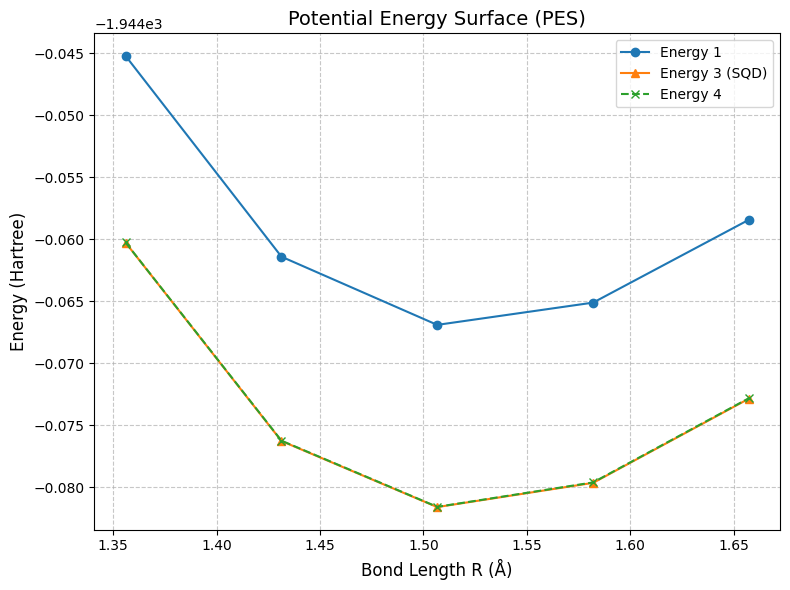

In [ ]:
import matplotlib.pyplot as plt

# ログから抽出したデータ
R_values = [1.3560, 1.4314, 1.5067, 1.5821, 1.6574]

# 各エネルギー列のデータ
# （名称はお使いの手法に合わせて適宜変更してください 例: HF, VQE_raw, SQD, Exact）
E1 = [-1944.04520471, -1944.06140860, -1944.06690951, -1944.06511236, -1944.05842918]
E2 = [-1946.84696472, -1946.86418591, -1946.87119847, -1946.87134649, -1946.86698473]
E3 = [-1944.06027096, -1944.07628235, -1944.08161113, -1944.07965569, -1944.07286481]
E4 = [-1944.06025824, -1944.07625511, -1944.08159243, -1944.07962123, -1944.07282853]

# プロットの設定
plt.figure(figsize=(8, 6))

# プロットの実行
plt.plot(R_values, E1, marker='o', linestyle='-', label='Energy 1')
plt.plot(R_values, E3, marker='^', linestyle='-', label='Energy 3 (SQD)')
plt.plot(R_values, E4, marker='x', linestyle='--', label='Energy 4')

# 注意: E2は値が大きく外れているため（-1946.8近辺）、他のデータ（-1944.0近辺）と
# 同時描画するとグラフが潰れます。E2も確認したい場合は以下のコメントアウトを外してください。
# plt.plot(R_values, E2, marker='s', linestyle=':', label='Energy 2')

# グラフの装飾
plt.xlabel('Bond Length R (Å)', fontsize=12)
plt.ylabel('Energy (Hartree)', fontsize=12)
plt.title('Potential Energy Surface (PES)', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)

# レイアウトの調整と表示
plt.tight_layout()
plt.show()

# 1個だけ実行できたから、次も続きから

✅ パッケージ読み込み完了
✅ 設定完了
   CAS(12e, 12o) → 24 量子ビット
   基底: 6-31g  LUCJ層: 1  ショット: 500
  PubChem REST API から CID 9554 の 3D 座標を取得中...


qiskit_runtime_service._discover_account:WARNING:2026-04-17 06:04:31,248: Loading account with the given token. A saved account will not be used.


  ✅ 取得完了: 26 原子
  組成: {'F': 15, 'O': 2, 'C': 8, 'H': 1}
  原子数: 26
  スキャン対象結合: C24–C22
  平衡結合距離: 1.5067 Å
  C24 (C): (3.539, 0.591, -0.167)
  C22 (C): (2.630, -0.597, -0.348)

  PES スキャン距離: ['1.2054', '1.2958', '1.3560', '1.4314', '1.5067', '1.5821', '1.6574', '2.0039', '2.5012', '3.0134', '3.7668', '4.5352']
✅ 座標変位関数定義完了
✅ 接続完了
   バックエンド: ibm_fez
   量子ビット数: 156
   必要量子ビット: 24
✅ 関数定義完了
  PFOA PES スキャン開始
  CAS(12e, 12o)  基底: 6-31g
  backend=ibm_fez  reps=1  shots=500
  スキャン結合: C24–C22  平衡距離: 1.5067 Å

     R |             HF |            MP2 |          CASCI |            SQD |   Err mHa |  It
--------------------------------------------------------------------------------------------

--- R = 1.2054 Å (factor = 0.80) ---
  Step 1: PySCF 計算中...
  Step 2: LUCJ 回路構築 (24 qubits)...
  Step 3: 実機サンプリング投入中...
      Job ID: d7gsue493s0c738s0re0
      gates: {'sx': 2182, 'cz': 1081, 'rz': 1063, 'x': 197, 'measure': 24, 'barrier': 1}
  → 取得完了
  Step 4: SQD ポストプロセッシング...
1.2054 | -1943.95951264 | -

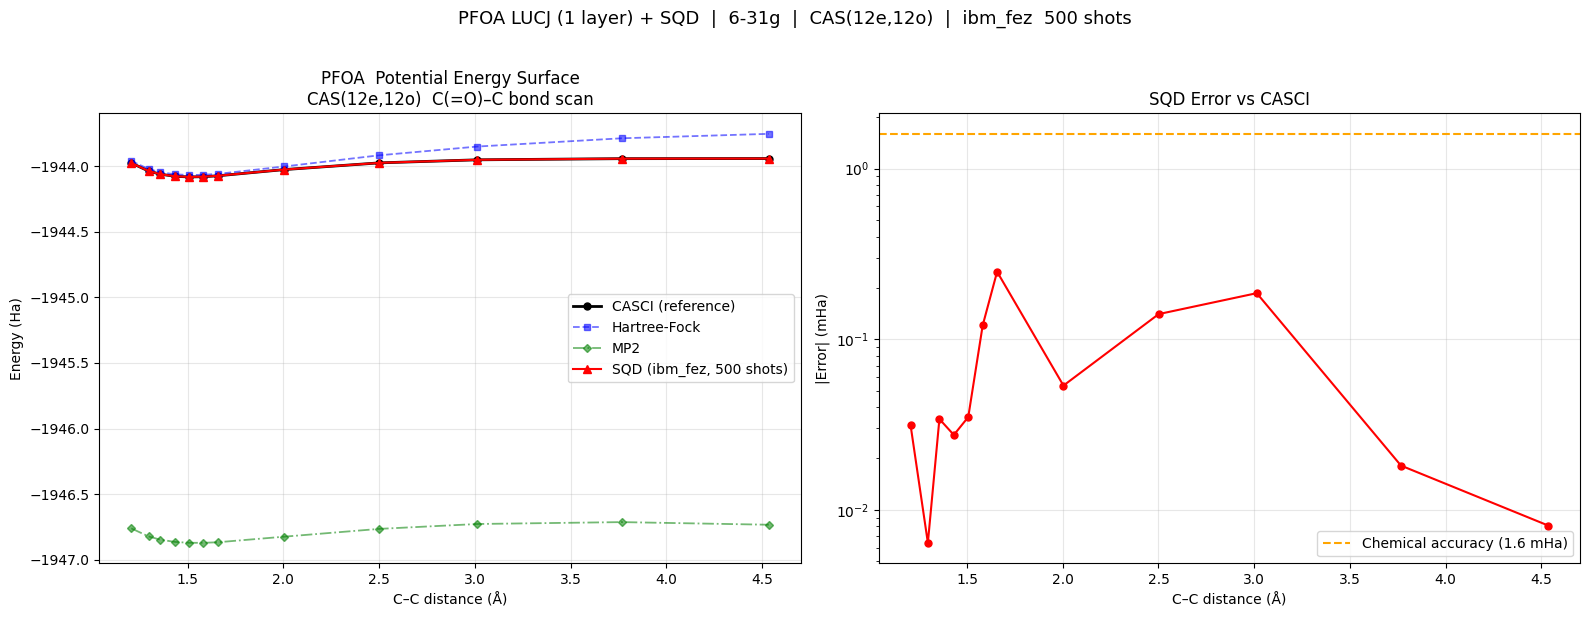

✅ pfoa_pes_hardware.png 保存

────────────────────────────────────────────────────────────
  分子:          PFOA (C₈HF₁₅O₂)
  PubChem CID:   9554
  バックエンド:  ibm_fez
  量子ビット数:  24
  基底関数:      6-31g
  活性空間:      CAS(12e, 12o)
  LUCJ 層数:     1
  ショット数:    500
  スキャン結合:  C24–C22  (C(=O)–C)
────────────────────────────────────────────────────────────
  CASCI 平衡距離: 1.5067 Å → -1944.08161113 Ha
  SQD   平衡距離: 1.5067 Å → -1944.08157616 Ha
  平均誤差:       0.0758 mHa
  最大誤差:       0.2486 mHa
  化学精度内:     12/12 点
────────────────────────────────────────────────────────────


In [ ]:
#!/usr/bin/env python3
"""
PFOA (C₈HF₁₅O₂) PES — LUCJ + SQD  【IBM Quantum 実機専用】
============================================================================
C–C 結合スキャンによるポテンシャルエネルギー曲面の計算。
活性空間: CAS(12e, 12o) = 24 量子ビット

PubChem (CID 9554) から 3D 座標を取得し、
指定した C–C 結合を伸縮させて PES を描画します。

pip install "qiskit>=1.0" "qiskit-ibm-runtime>=0.28" "qiskit-addon-sqd>=0.12.0" \
            "pyscf>=2.7" "ffsim>=0.0.47" matplotlib numpy requests

※ PFOA は大規模分子のため CCSD は計算コストが非現実的。
   LUCJ ansatz の初期パラメータには MP2 の t2 振幅を使用し、
   リファレンスは HF + CASCI(12e,12o) のみとする。
"""


# ============================================================
# セル 1: パッケージ読み込み
# ============================================================
import warnings; warnings.filterwarnings("ignore")
import time as _time
import json
from functools import partial
from copy import deepcopy

import numpy as np
import matplotlib.pyplot as plt
import requests

import pyscf, pyscf.mp, pyscf.mcscf, pyscf.ao2mo
import ffsim
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
from qiskit_addon_sqd.fermion import (
    SCIResult, diagonalize_fermionic_hamiltonian, solve_sci_batch,
)

print("✅ パッケージ読み込み完了")


# ============================================================
# セル 2: ユーザー設定  ― ここだけ編集すれば OK
# ============================================================

# ----- PubChem 設定 ---------------------------------------------------------
PUBCHEM_CID = 9554                          # PFOA の CID

# ----- PES スキャン対象の C–C 結合 -------------------------------------------
#   PFOA: F₃C-CF₂-CF₂-CF₂-CF₂-CF₂-CF₂-COOH
#   C1(=O)(O)–C2 結合 (カルボキシル基-隣接 CF₂ 間) をスキャンする。
#   SCAN_ATOM_INDICES: PubChem 3D 座標中の 0-indexed 原子番号
#   (取得後に自動検出するので、手動変更は不要)
SCAN_BOND = "C-C(=O)"   # カルボキシル C と隣接 C の結合をスキャン

# セル 2：ユーザー設定
# 変更前 (10点)
# BOND_FACTORS = [0.85, 0.90, 0.95, 1.00, 1.05, 1.10, 1.20, 1.40, 1.60, 2.00]


BOND_FACTORS = [
    0.80, 0.86,                     # 短距離側 (R ≒ 1.21 Å, 1.30 Å)
    0.90, 0.95, 1.00, 1.05, 1.10,   # 取得済みの計算範囲 (R ≒ 1.36 Å 〜 1.66 Å)
    1.33, 1.66, 2.00, 2.50, 3.01                # 長距離側 (R ≒ 2.00 Å, 2.50 Å, 3.01 Å)
]



# ----- 分子計算の設定 --------------------------------------------------------
BASIS = "6-31g"                          # 基底関数

# ----- CAS 空間 (14 電子, 14 軌道) -------------------------------------------
CAS_NELEC = 12                              # 活性電子数
CAS_NORB  = 12                              # 活性軌道数

# ----- LUCJ ansatz ----------------------------------------------------------
N_REPS = 1                                  # LUCJ 層数

# ----- サンプリング ----------------------------------------------------------
SHOTS = 500                                # サンプリングショット数

# ----- SQD パラメータ --------------------------------------------------------
SQD_ITERATIONS     = 5                      # 自己整合ループの最大反復
NUM_BATCHES        = 5                      # サブサンプルバッチ数
SAMPLES_PER_BATCH  = 300                    # 1 バッチあたりのビット列数
MAX_DAVIDSON_CYCLE = 200                    # Selected CI の最大反復
ENERGY_TOL         = 1e-3                   # エネルギー収束閾値 (Ha)
OCCUPANCIES_TOL    = 1e-3                   # 軌道占有数の収束閾値

# ----- 乱数シード -----------------------------------------------------------
RAND_SEED = 42

print("✅ 設定完了")
print(f"   CAS({CAS_NELEC}e, {CAS_NORB}o) → {2 * CAS_NORB} 量子ビット")
print(f"   基底: {BASIS}  LUCJ層: {N_REPS}  ショット: {SHOTS}")


# ============================================================
# セル 3: PubChem から PFOA の 3D 座標を取得
# ============================================================

def fetch_pubchem_3d(cid: int) -> list[dict]:
    """PubChem REST API から 3D SDF を取得し、原子座標リストを返す。"""
    # --- 方法 1: PubChem REST API (JSON 3D) ---
    url = (f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/cid/{cid}"
           f"/JSON?record_type=3d")
    print(f"  PubChem REST API から CID {cid} の 3D 座標を取得中...")

    try:
        resp = requests.get(url, timeout=30)
        resp.raise_for_status()
        data = resp.json()

        atoms_block = data["PC_Compounds"][0]["atoms"]
        coords_block = data["PC_Compounds"][0]["coords"][0]["conformers"][0]

        elements_map = {6: "C", 1: "H", 9: "F", 8: "O", 7: "N",
                        15: "P", 16: "S", 17: "Cl", 35: "Br"}
        aids = atoms_block["aid"]          # atom IDs (1-indexed)
        elems = atoms_block["element"]     # atomic numbers
        xs = coords_block["x"]
        ys = coords_block["y"]
        zs = coords_block["z"]

        atoms = []
        for i in range(len(aids)):
            sym = elements_map.get(elems[i], f"X{elems[i]}")
            atoms.append(dict(symbol=sym, x=xs[i], y=ys[i], z=zs[i]))

        formula = "".join(a["symbol"] for a in atoms)
        print(f"  ✅ 取得完了: {len(atoms)} 原子")
        return atoms

    except Exception as e:
        print(f"  ⚠ PubChem API エラー: {e}")
        print(f"  → フォールバック座標を使用します")
        return _pfoa_fallback_coords()


def _pfoa_fallback_coords() -> list[dict]:
    """PubChem 接続不可時のフォールバック (MMFF94 最適化済み座標)。"""
    # PubChem CID 9554 の 3D conformer (MMFF94s) から抽出
    raw = """
C  -0.2940  -0.0070   0.0050
C   1.2080   0.0120  -0.0010
C   1.7690   1.4150  -0.0100
C   3.2810   1.4040   0.0050
C   3.8410   2.8070  -0.0040
C   5.3530   2.7970   0.0100
C   5.9120   4.1990  -0.0000
C   7.4230   4.1870   0.0160
O  -0.8510  -1.1110   0.0100
O  -0.9610   1.1690   0.0010
H  -1.9220   1.0450   0.0060
F   1.5900  -0.6420  -1.1180
F   1.5830  -0.6560   1.1070
F   1.3590   2.0590  -1.1260
F   1.3520   2.0730   1.0970
F   3.6900   0.7530   1.1210
F   3.6960   0.7400  -1.1030
F   3.4320   3.4510   1.1120
F   3.4380   3.4380  -1.1270
F   5.7620   2.1450   1.1260
F   5.7680   2.1320  -1.1000
F   5.5040   4.8430  -1.1170
F   5.5100   4.8300   1.1160
F   7.7850   3.5540   1.1330
F   7.7920   3.5410  -1.1000
F   7.9480   5.4350   0.0220
"""
    atoms = []
    for line in raw.strip().split("\n"):
        parts = line.split()
        atoms.append(dict(symbol=parts[0],
                          x=float(parts[1]),
                          y=float(parts[2]),
                          z=float(parts[3])))
    return atoms


# --- 座標取得 ---
pfoa_atoms = fetch_pubchem_3d(PUBCHEM_CID)

# 元素ごとにカウント
from collections import Counter
elem_count = Counter(a["symbol"] for a in pfoa_atoms)
print(f"  組成: {dict(elem_count)}")
print(f"  原子数: {len(pfoa_atoms)}")


# ============================================================
# セル 4: PES スキャン対象の C–C 結合を自動検出
# ============================================================

def find_carboxyl_cc_bond(atoms: list[dict]) -> tuple[int, int]:
    """
    PFOA のカルボキシル基 C(=O)(OH) と隣接 CF₂ の C–C 結合を検出。
    戻り値: (C_carboxyl_idx, C_cf2_idx)  ← 0-indexed
    """
    coords = np.array([[a["x"], a["y"], a["z"]] for a in atoms])
    symbols = [a["symbol"] for a in atoms]

    # 全 C 原子のインデックス
    c_indices = [i for i, s in enumerate(symbols) if s == "C"]
    o_indices = [i for i, s in enumerate(symbols) if s == "O"]

    # カルボキシル C = O 原子 2 つ以上に結合している C
    carboxyl_c = None
    for ci in c_indices:
        o_neighbors = 0
        for oi in o_indices:
            dist = np.linalg.norm(coords[ci] - coords[oi])
            if dist < 1.6:  # C-O or C=O 結合距離
                o_neighbors += 1
        if o_neighbors >= 2:
            carboxyl_c = ci
            break

    if carboxyl_c is None:
        raise ValueError("カルボキシル C が見つかりませんでした")

    # カルボキシル C に最も近い他の C を見つける
    min_dist = float("inf")
    adjacent_c = None
    for ci in c_indices:
        if ci == carboxyl_c:
            continue
        dist = np.linalg.norm(coords[carboxyl_c] - coords[ci])
        if dist < min_dist:
            min_dist = dist
            adjacent_c = ci

    print(f"  スキャン対象結合: C{carboxyl_c}–C{adjacent_c}")
    print(f"  平衡結合距離: {min_dist:.4f} Å")
    print(f"  C{carboxyl_c} ({symbols[carboxyl_c]}): "
          f"({coords[carboxyl_c][0]:.3f}, {coords[carboxyl_c][1]:.3f}, "
          f"{coords[carboxyl_c][2]:.3f})")
    print(f"  C{adjacent_c} ({symbols[adjacent_c]}): "
          f"({coords[adjacent_c][0]:.3f}, {coords[adjacent_c][1]:.3f}, "
          f"{coords[adjacent_c][2]:.3f})")

    return carboxyl_c, adjacent_c, min_dist


idx_c1, idx_c2, eq_dist = find_carboxyl_cc_bond(pfoa_atoms)

# PES の結合距離リスト
BOND_LENGTHS = [eq_dist * f for f in BOND_FACTORS]
print(f"\n  PES スキャン距離: {[f'{d:.4f}' for d in BOND_LENGTHS]}")


# ============================================================
# セル 5: 結合距離を変更した座標を生成する関数
# ============================================================

def make_displaced_geometry(atoms, idx_a, idx_b, new_dist):
    """
    原子 idx_a を固定し、idx_b 側のフラグメントを
    結合軸に沿って移動させ、A–B 距離を new_dist にする。

    フラグメント分割: idx_a–idx_b 結合を切断し、
    idx_b 側に連結する原子群を移動する。
    """
    coords = np.array([[a["x"], a["y"], a["z"]] for a in atoms])
    symbols = [a["symbol"] for a in atoms]
    n = len(atoms)

    # 結合グラフを構築 (共有結合距離テーブル)
    cov_radii = {"C": 0.77, "H": 0.32, "O": 0.73, "F": 0.64,
                 "N": 0.71, "S": 1.03, "P": 1.10, "Cl": 0.99, "Br": 1.14}
    adjacency = {i: set() for i in range(n)}
    for i in range(n):
        for j in range(i+1, n):
            ri = cov_radii.get(symbols[i], 0.8)
            rj = cov_radii.get(symbols[j], 0.8)
            if np.linalg.norm(coords[i] - coords[j]) < 1.3 * (ri + rj):
                adjacency[i].add(j)
                adjacency[j].add(i)

    # BFS: idx_b 側のフラグメント (idx_a–idx_b 結合を除く)
    visited = {idx_b}
    queue = [idx_b]
    while queue:
        node = queue.pop(0)
        for nb in adjacency[node]:
            if nb not in visited and nb != idx_a:
                visited.add(nb)
                queue.append(nb)

    fragment_b = visited

    # 現在の A–B ベクトル
    vec_ab = coords[idx_b] - coords[idx_a]
    current_dist = np.linalg.norm(vec_ab)
    direction = vec_ab / current_dist
    shift = direction * (new_dist - current_dist)

    # フラグメント B を平行移動
    new_coords = coords.copy()
    for i in fragment_b:
        new_coords[i] += shift

    # PySCF 用の atom リストを生成
    atom_list = []
    for i in range(n):
        atom_list.append([symbols[i],
                          (new_coords[i][0], new_coords[i][1], new_coords[i][2])])

    return atom_list


print("✅ 座標変位関数定義完了")


# ============================================================
# セル 6: IBM Quantum 認証 & バックエンド選択
# ============================================================
IBM_TOKEN    = ""     # ← ここに API Token を貼り付け
INSTANCE     = ""     # ← CRN を貼り付け (新プラットフォームでは省略可)
BACKEND_NAME = None                       # None → least_busy で自動選択

service = QiskitRuntimeService(
    channel="ibm_quantum_platform",
    token=IBM_TOKEN,
    instance=INSTANCE if INSTANCE else None,
)

if BACKEND_NAME is None:
    backend = service.least_busy(operational=True, simulator=False,
                                  min_num_qubits=2*CAS_NORB)
else:
    backend = service.backend(BACKEND_NAME)

print(f"✅ 接続完了")
print(f"   バックエンド: {backend.name}")
print(f"   量子ビット数: {backend.num_qubits}")
print(f"   必要量子ビット: {2 * CAS_NORB}")


# ============================================================
# セル 7: 関数定義  ― Step 1〜4
# ============================================================

# ----- Step 1: PySCF で分子積分 + MP2 + CASCI -----
def compute_molecule(atom_list: list, cas_norb: int, cas_nelec: int):
    """
    PySCF で PFOA の RHF → MP2 → CASCI(14e,14o) を計算。
    LUCJ ansatz の初期パラメータには MP2 の t2 振幅を使用。
    (CCSD は PFOA サイズでは計算コストが大きすぎるため除外)

    Parameters
    ----------
    atom_list : list of [symbol, (x, y, z)]
    cas_norb  : 活性軌道数
    cas_nelec : 活性電子数

    Returns
    -------
    dict : hcore, eri, e_nuc, norb, nelec, hf, mp2, casci, t1, t2
    """
    mol = pyscf.gto.Mole()
    mol.build(atom=atom_list, basis=BASIS, verbose=0, max_memory=8000)

    # --- RHF ---
    mf = pyscf.scf.RHF(mol)
    mf.verbose = 0
    mf.max_cycle = 200
    mf.run()
    if not mf.converged:
        print("    ⚠ RHF 未収束 → SOSCF で再試行")
        mf = mf.newton()
        mf.verbose = 0
        mf.run()

    # --- MP2 (フル空間, O(N⁵) で CCSD より大幅に軽量) ---
    mp2 = pyscf.mp.MP2(mf)
    mp2.verbose = 0
    mp2.run()
    mp2_e = mp2.e_tot

    # CAS 空間サイズに合わせた t2 のスライス
    nocc = mol.nelec[0]           # alpha 占有軌道数
    ncore = nocc - cas_nelec // 2 # frozen core 軌道数
    nocc_cas = cas_nelec // 2     # 活性占有軌道数
    nvir_cas = cas_norb - nocc_cas # 活性仮想軌道数

    # MP2 は t1 を持たないのでゼロ行列
    t1_cas = np.zeros((nocc_cas, nvir_cas))
    t2_cas = mp2.t2[ncore:ncore+nocc_cas,
                     ncore:ncore+nocc_cas,
                     :nvir_cas, :nvir_cas]

    # --- CASCI(14e,14o) ---
    cas = pyscf.mcscf.CASCI(mf, cas_norb, cas_nelec)
    cas.verbose = 0
    cas.max_cycle_macro = 200
    # CAS 軌道を frozen core の上から取得
    total_orbs = mol.nao_nr()
    ncore_orbs = (mol.nelec[0] + mol.nelec[1]) // 2 - cas_nelec // 2
    active_orb_list = list(range(ncore_orbs, ncore_orbs + cas_norb))

    # 1e/2e 積分の取得
    mo = cas.sort_mo(active_orb_list, base=0)
    hcore, e_nuc = cas.get_h1cas(mo)
    eri = pyscf.ao2mo.restore(1, cas.get_h2cas(mo), cas_norb)

    try:
        cas.run()
        casci_e = cas.e_tot
    except Exception as e:
        print(f"    ⚠ CASCI エラー: {e}")
        casci_e = mf.e_tot  # フォールバック

    return dict(
        hcore=hcore, eri=eri, e_nuc=e_nuc,
        norb=cas_norb,
        nelec=(cas_nelec // 2, cas_nelec // 2),
        hf=mf.e_tot, mp2=mp2_e, casci=casci_e,
        t1=t1_cas, t2=t2_cas,
        total_orbs=total_orbs,
    )


# ----- Step 2: LUCJ 回路の構築 (ffsim) -----
def build_lucj_circuit(norb, nelec, t1, t2):
    """
    LUCJ ansatz 回路を構築。

    Parameters
    ----------
    norb  : 活性軌道数 (= CAS_NORB)
    nelec : (nalpha, nbeta)
    t1    : t1 振幅 (MP2 ではゼロ行列)
    t2    : MP2 t2 振幅 (活性空間にスライス済み)
    """
    pairs_aa = [(p, p+1) for p in range(norb - 1)]
    pairs_ab = [(p, p)   for p in range(norb)]

    ucj_op = ffsim.UCJOpSpinBalanced.from_t_amplitudes(
        t2=t2, t1=t1, n_reps=N_REPS,
        interaction_pairs=(pairs_aa, pairs_ab),
    )

    n_qubits = 2 * norb
    qr = QuantumRegister(n_qubits, "q")
    qc = QuantumCircuit(qr)
    qc.append(ffsim.qiskit.PrepareHartreeFockJW(norb, nelec), qr)
    qc.append(ffsim.qiskit.UCJOpSpinBalancedJW(ucj_op), qr)
    qc.measure_all()
    return qc


# ----- Step 3: 実機でサンプリング -----
def sample_on_hardware(qc, norb):
    """IBM Quantum 実機でサンプリング。"""
    n_qubits = 2 * norb
    initial_layout = list(range(n_qubits))

    pm = generate_preset_pass_manager(
        optimization_level=3, backend=backend,
        initial_layout=initial_layout,
    )
    pm.pre_init = ffsim.qiskit.PRE_INIT
    isa = pm.run(qc)

    sampler = Sampler(mode=backend)
    sampler.options.default_shots = SHOTS
    sampler.options.dynamical_decoupling.enable = True
    sampler.options.dynamical_decoupling.sequence_type = "XpXm"
    sampler.options.twirling.enable_gates = True

    job = sampler.run([isa])
    print(f"      Job ID: {job.job_id()}")
    print(f"      gates: {dict(isa.count_ops())}")
    bit_array = job.result()[0].data.meas
    return bit_array


# ----- Step 4: SQD ポストプロセッシング -----
def run_sqd(hcore, eri, bit_array, norb, nelec, e_nuc, seed):
    """SQD (Sample-based Quantum Diagonalization) を実行。"""
    rng = np.random.default_rng(seed)
    solver = partial(solve_sci_batch, spin_sq=0.0,
                     max_cycle=MAX_DAVIDSON_CYCLE)

    energies = []
    def _cb(results):
        energies.append(min(r.energy for r in results) + e_nuc)

    res = diagonalize_fermionic_hamiltonian(
        hcore, eri, bit_array,
        samples_per_batch=SAMPLES_PER_BATCH,
        norb=norb, nelec=nelec,
        num_batches=NUM_BATCHES,
        energy_tol=ENERGY_TOL,
        occupancies_tol=OCCUPANCIES_TOL,
        max_iterations=SQD_ITERATIONS,
        sci_solver=solver,
        symmetrize_spin=True,
        carryover_threshold=1e-4,
        callback=_cb, seed=rng,
    )
    return res.energy + e_nuc, energies


print("✅ 関数定義完了")


# ============================================================
# セル 8: PES スキャン実行
# ============================================================
print("=" * 70)
print(f"  PFOA PES スキャン開始")
print(f"  CAS({CAS_NELEC}e, {CAS_NORB}o)  基底: {BASIS}")
print(f"  backend={backend.name}  reps={N_REPS}  shots={SHOTS}")
print(f"  スキャン結合: C{idx_c1}–C{idx_c2}  平衡距離: {eq_dist:.4f} Å")
print("=" * 70)

hdr = (f"{'R':>6} | {'HF':>14} | {'MP2':>14} | "
       f"{'CASCI':>14} | {'SQD':>14} | {'Err mHa':>9} | {'It':>3}")
print(f"\n{hdr}\n{'-' * len(hdr)}")

results = []
t0 = _time.time()

for i, r in enumerate(BOND_LENGTHS):
    print(f"\n--- R = {r:.4f} Å (factor = {BOND_FACTORS[i]:.2f}) ---")

    # 座標生成
    atom_list = make_displaced_geometry(pfoa_atoms, idx_c1, idx_c2, r)

    # Step 1: 古典計算
    print(f"  Step 1: PySCF 計算中...", flush=True)
    mol = compute_molecule(atom_list, CAS_NORB, CAS_NELEC)

    # Step 2: 回路構築
    print(f"  Step 2: LUCJ 回路構築 ({2*CAS_NORB} qubits)...", flush=True)
    qc = build_lucj_circuit(mol["norb"], mol["nelec"],
                            mol["t1"], mol["t2"])

    # Step 3: 実機サンプリング
    print(f"  Step 3: 実機サンプリング投入中...", flush=True)
    ba = sample_on_hardware(qc, mol["norb"])
    print(f"  → 取得完了", flush=True)

    # Step 4: SQD
    print(f"  Step 4: SQD ポストプロセッシング...", flush=True)
    seed = RAND_SEED + i
    sqd_e, hist = run_sqd(mol["hcore"], mol["eri"], ba,
                          mol["norb"], mol["nelec"],
                          mol["e_nuc"], seed)

    err = abs(sqd_e - mol["casci"]) * 1000
    results.append(dict(r=r, factor=BOND_FACTORS[i],
                        hf=mol["hf"], mp2=mol["mp2"],
                        casci=mol["casci"], sqd=sqd_e, hist=hist,
                        nq=qc.num_qubits))

    print(f"{r:6.4f} | {mol['hf']:14.8f} | {mol['mp2']:14.8f} | "
          f"{mol['casci']:14.8f} | {sqd_e:14.8f} | {err:9.4f} | "
          f"{len(hist):3d}")

elapsed = _time.time() - t0
print(f"\n✅ 完了! 計算時間: {elapsed:.1f}s")


# ============================================================
# セル 9: プロット
# ============================================================
rs    = [d["r"]     for d in results]
hf_e  = [d["hf"]    for d in results]
mp2_e = [d["mp2"]   for d in results]
cas_e = [d["casci"] for d in results]
sqd_e = [d["sqd"]   for d in results]
errs  = np.abs(np.array(sqd_e) - np.array(cas_e)) * 1000

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# (a) PES
ax1.plot(rs, cas_e, "k-o",  ms=5, lw=2,   label="CASCI (reference)")
ax1.plot(rs, hf_e,  "b--s", ms=4, lw=1.3, alpha=.55, label="Hartree-Fock")
ax1.plot(rs, mp2_e, "g-.D", ms=4, lw=1.3, alpha=.55, label="MP2")
ax1.plot(rs, sqd_e, "r-^",  ms=6, lw=1.5,
         label=f"SQD ({backend.name}, {SHOTS} shots)")
ax1.set(xlabel="C–C distance (Å)", ylabel="Energy (Ha)",
        title="PFOA  Potential Energy Surface\n"
              f"CAS({CAS_NELEC}e,{CAS_NORB}o)  C(=O)–C bond scan")
ax1.legend(); ax1.grid(alpha=.3)

# (b) Error
ax2.semilogy(rs, np.maximum(errs, 1e-10), "r-o", ms=5, lw=1.5)
ax2.axhline(1.6, color="orange", ls="--", lw=1.5,
            label="Chemical accuracy (1.6 mHa)")
ax2.set(xlabel="C–C distance (Å)", ylabel="|Error| (mHa)",
        title="SQD Error vs CASCI")
ax2.legend(); ax2.grid(alpha=.3)

plt.suptitle(
    f"PFOA LUCJ ({N_REPS} layer) + SQD  |  {BASIS}  |  "
    f"CAS({CAS_NELEC}e,{CAS_NORB}o)  |  "
    f"{backend.name}  {SHOTS} shots",
    y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig("pfoa_pes_hardware.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ pfoa_pes_hardware.png 保存")


# ============================================================
# セル 10: サマリー
# ============================================================
ci = int(np.argmin(cas_e))
si = int(np.argmin(sqd_e))

print(f"\n{'─' * 60}")
print(f"  分子:          PFOA (C₈HF₁₅O₂)")
print(f"  PubChem CID:   {PUBCHEM_CID}")
print(f"  バックエンド:  {backend.name}")
print(f"  量子ビット数:  {results[0]['nq']}")
print(f"  基底関数:      {BASIS}")
print(f"  活性空間:      CAS({CAS_NELEC}e, {CAS_NORB}o)")
print(f"  LUCJ 層数:     {N_REPS}")
print(f"  ショット数:    {SHOTS}")
print(f"  スキャン結合:  C{idx_c1}–C{idx_c2}  (C(=O)–C)")
print(f"{'─' * 60}")
print(f"  CASCI 平衡距離: {BOND_LENGTHS[ci]:.4f} Å → {cas_e[ci]:.8f} Ha")
print(f"  SQD   平衡距離: {BOND_LENGTHS[si]:.4f} Å → {sqd_e[si]:.8f} Ha")
print(f"  平均誤差:       {np.mean(errs):.4f} mHa")
print(f"  最大誤差:       {np.max(errs):.4f} mHa")
print(f"  化学精度内:     {np.sum(errs < 1.6)}/{len(errs)} 点")
print(f"{'─' * 60}")